In [9]:
import requests
from bs4 import BeautifulSoup as bs
import json

In [6]:
# requests: 브라우저(요청 도구, 응답 처리 도구)
requests.get()  # get요청
requests.post() # post요청

In [4]:
response = requests.get("https://jsonplaceholder.typicode.com/users")

## 역직렬화

In [15]:
# .loads(): json -> python 객체
datas = json.loads(response.text)

## 직렬화 

In [16]:
datas = json.dumps(datas)

In [18]:
url = "https://www.melon.com/chart/index.htm"
headers = {"User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/131.0.0.0 Safari/537.36"}

response = requests.get(url, headers=headers)

In [20]:
# BeautifulSoup: html parser
soup = bs(response.text, "html.parser")

In [23]:
# 선택자 선택이 가능
soup.find("span", class_="hour")

<span class="hour">16:00</span>

In [24]:
soup.select("span.hour")

[<span class="hour">16:00</span>]

In [26]:
# .text: 태그의 내용
soup.select_one("span.hour").text

'16:00'

In [29]:
song_list = soup.select("tbody tr")

In [33]:
song_td = song_list[1].select("td")[5]
song_title = song_td.select("a")[0].text
singer = song_td.select("a")[1].text

print(song_title)
print(singer)

기쁨, 슬픔, 아름다운 마음
AKMU (악뮤)


In [49]:
song_datas = []

for i, tag in enumerate(song_list):
    song_td = song_list[i].select("td")[5]
    song_title = song_td.select("a")[0].text
    singer = song_td.select("a")[1].text

    song_datas.append((str((i + 1)) + "위", song_title, singer))

In [48]:
song_datas

[('1위', '소문의 낙원', 'AKMU\xa0(악뮤)'),
 ('2위', '기쁨, 슬픔, 아름다운 마음', 'AKMU\xa0(악뮤)'),
 ('3위', 'REDRED', 'CORTIS\xa0(코르티스)'),
 ('4위', 'RUDE!', 'Hearts2Hearts\xa0(하츠투하츠)'),
 ('5위', 'It′s Me', '아일릿(ILLIT)'),
 ('6위', 'BANG BANG', 'IVE\xa0(아이브)'),
 ('7위', '사랑하게 될 거야', '한로로'),
 ('8위', '캐치 캐치', 'YENA\xa0(최예나)'),
 ('9위', '404 (New Era)', 'KiiiKiii\xa0(키키)'),
 ('10위', 'Drowning', 'WOODZ'),
 ('11위', '0+0', '한로로'),
 ('12위', 'SWIM', '방탄소년단'),
 ('13위', 'Good Goodbye', '화사\xa0(HWASA)'),
 ('14위', '타임캡슐', '다비치'),
 ('15위', 'Popcorn', '도경수(D.O.)'),
 ('16위', '너에게 닿기를', '10CM'),
 ('17위', '멸종위기사랑', '이찬혁'),
 ('18위', 'Body to Body', '방탄소년단'),
 ('19위', '어떻게 이별까지 사랑하겠어, 널 사랑하는 거지', 'AKMU\xa0(악뮤)'),
 ('20위', '그대 작은 나의 세상이 되어', '카더가든'),
 ('21위', '어제보다 슬픈 오늘', '우디\xa0(Woody)'),
 ('22위', 'Blue Valentine', 'NMIXX'),
 ('23위', '너의 모든 순간', '성시경'),
 ('24위', '뛰어(JUMP)', 'BLACKPINK'),
 ('25위', 'Golden', 'HUNTR/X'),
 ('26위', '모르시나요(PROD.로코베리)', '조째즈'),
 ('27위', '2.0', '방탄소년단'),
 ('28위', 'toxic till the end', '로제\xa0(ROSÉ)'),
 ('

In [122]:
import csv
import os
finance_list = soup.select("tbody tr")

In [123]:
# r"": 경로 이슈 해결
folder_path = r"C:\back_0900_ngh\python\resource\csv"
file_name = "finance.csv"

file_path = os.path.join(folder_path, file_name)

In [124]:
with open(file_path, "w", newline="", encoding="utf-8-sig") as f:
    writer = csv.writer(f)

    writer.writerow(["순위", "종목명", "검색비율", "현재가" , "전일비", "등락률", "거래량", "시가", "고가"])
    writer.writerows(finance_datas)

In [125]:
url = "https://finance.naver.com/sise/lastsearch2.naver"
headers = {"User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/131.0.0.0 Safari/537.36"}

response = requests.get(url, headers=headers)

In [126]:
soup = bs(response.text, "html.parser")

In [131]:
finance_datas = []

for tag in (finance_list):
    if not tag.select_one("td.no"):
        continue
    tds = tag.select("td")
    rank          = tds[0].text.strip()   # 순위
    title         = tds[1].text.strip()   # 종목명
    search_rate   = tds[2].text.strip()   # 검색비율
    current_price = tds[3].text.strip()   # 현재가
    prev_diff     = tds[4].text.strip()   # 전일비
    change_rate   = tds[5].text.strip()   # 등락률
    volume        = tds[6].text.strip()   # 거래량
    open_price    = tds[7].text.strip()   # 시가
    high_price    = tds[8].text.strip()   # 고가
    
    finance_datas.append((rank, title, search_rate, current_price,
                          prev_diff, change_rate, volume, open_price, high_price))

print("finance_list 길이:", len(finance_list))
print("---")
print(soup.select_one("tbody"))  # tbody가 잡히는지 확인

finance_list 길이: 0
---
None


In [130]:
finance_datas

[]

## 셀레니움(Selenium)
- 셀레니움(Selenium)은 웹 브라우저를 자동으로 제어할 수 있는 오픈소스 툴로
웹 애플리케이션을 테스트하거나 크롤링하기 위해 사용되는 브라우저 자동화 도구이다.
Chrome, Firefox, Edge 등 여러가지 브라우저에서 작업이 가능하며,
동작하지 않는 브라우저도 존재하며, 로그인, 폼 제출, 버튼 클릭 등 작업을
자동화 할 수 있다

In [138]:
!pip install selenium

In [148]:
import selenium
from selenium.webdriver import Chrome # 크롬 자동화 도구
from selenium.webdriver.common.keys import Keys # 자동화 도구 키 제어
from selenium.webdriver.common.by import By

In [147]:
driver = Chrome()
url = "https://www.google.com/"
driver.get(url)

In [151]:
# driver.find_element("속성명", "속성값")
search = driver.find_element(By.CLASS_NAME, "gLFyf")
search.send_keys("고양이")

In [153]:
# 엔터
search.send_keys(Keys.RETURN)

In [159]:
url = "https://comic.naver.com/webtoon/detail?titleId=733074&no=273&week=mon"

In [170]:
import time

In [155]:
time.sleep(2)
print("2초 뒤에 실행")

2초 뒤에 실행


In [171]:
driver.get(url)
time.sleep(2)

soup = bs(driver.page_source)

<html lang="ko"><head>
<meta content="text/html; charset=utf-8" http-equiv="Content-type"/>
<meta content="IE=edge, chrome=1" http-equiv="X-UA-Compatible"/>
<meta content="article" property="og:type"/>
<meta content="네이버 웹툰" property="og:article:author"/>
<meta content="https://comic.naver.com" property="og:article:author:url"/>
<meta content="백수세끼 - 273화 오징어덮밥" property="og:title"/>
<meta content="https://shared-comic.pstatic.net/thumb/webtoon/733074/273/thumbnail_600x315_efb5f0aa-9d58-43e9-bcdb-ffd12f1f3f7a.jpg" property="og:image"/>
<title>백수세끼 - 273화 오징어덮밥 : 네이버 웹툰</title>
<link href="https://shared-comic.pstatic.net/favicon/favicon_96x96.ico" rel="icon" type="image/x-icon"/>
<link href="https://ssl.pstatic.net/static/wcc/kw/prod-1.0/index.css?v=202605111720" rel="stylesheet" type="text/css"/>
<link href="/39293056ef7d8bcbcde7.css" rel="stylesheet"/>
<script>
        if (/MSIE \d|Trident.*rv:/.test(navigator.userAgent)) {
            window.location = 'microsoft-edge:' + window.loc
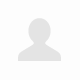
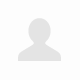
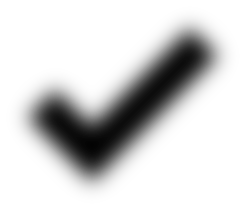

In [162]:
print(soup)

In [172]:
all_ready_button = driver.find_elements(By.CLASS_NAME, "_root_14no7_1")[1]

In [173]:
all_ready_button.click()

In [177]:
more_button = driver.find_element(By.CLASS_NAME, "eE2Vs")

In [176]:
for i in range(5):
    time.sleep(5)
    more_button.click()

StaleElementReferenceException: Message: stale element reference: stale element not found
  (Session info: chrome=147.0.7727.139); For documentation on this error, please visit: https://www.selenium.dev/documentation/webdriver/troubleshooting/errors#staleelementreferenceexception
Stacktrace:
	chromedriver!GetHandleVerifier [0x7ff76883a8e5+14e45]
	chromedriver!GetHandleVerifier [0x7ff76883a950+14eb0]
	chromedriver!(No symbol) [0x7ff7685ad6ed]
	chromedriver!(No symbol) [0x7ff7685c4dfe]
	chromedriver!(No symbol) [0x7ff7685c3500]
	chromedriver!(No symbol) [0x7ff7685b632b]
	chromedriver!(No symbol) [0x7ff7685b40ce]
	chromedriver!(No symbol) [0x7ff7685b8795]
	chromedriver!(No symbol) [0x7ff7685b885f]
	chromedriver!(No symbol) [0x7ff768608fc0]
	chromedriver!(No symbol) [0x7ff7685fb12f]
	chromedriver!(No symbol) [0x7ff76863002a]
	chromedriver!(No symbol) [0x7ff7685faa46]
	chromedriver!(No symbol) [0x7ff76865483b]
	chromedriver!(No symbol) [0x7ff7685f90e8]
	chromedriver!(No symbol) [0x7ff7685f9

In [178]:
def get_reply():
    try:
        driver = Chrome()
    
        url = "https://comic.naver.com/webtoon/detail?titleId=733074&no=273&week=mon"
        driver.get(url)
    
        time.sleep(3)
        all_reply_button = driver.find_elements(By.CLASS_NAME, "_root_14no7_1")[1]
        all_reply_button.click()
    
        time.sleep(3)
        more_button = driver.find_element(By.CLASS_NAME, "eE2Vs")
        for i in range(5):
            time.sleep(5)
            more_button.click()
            
        soup = bs(driver.page_source)
        return soup    
        
    
    except StaleElementReferenceException:
        soup = bs(driver.page_source)
        return soup

<html lang="ko"><head>
<meta content="text/html; charset=utf-8" http-equiv="Content-type"/>
<meta content="IE=edge, chrome=1" http-equiv="X-UA-Compatible"/>
<meta content="article" property="og:type"/>
<meta content="네이버 웹툰" property="og:article:author"/>
<meta content="https://comic.naver.com" property="og:article:author:url"/>
<meta content="백수세끼 - 273화 오징어덮밥" property="og:title"/>
<meta content="https://shared-comic.pstatic.net/thumb/webtoon/733074/273/thumbnail_600x315_efb5f0aa-9d58-43e9-bcdb-ffd12f1f3f7a.jpg" property="og:image"/>
<title>백수세끼 - 273화 오징어덮밥 : 네이버 웹툰</title>
<link href="https://shared-comic.pstatic.net/favicon/favicon_96x96.ico" rel="icon" type="image/x-icon"/>
<link href="https://ssl.pstatic.net/static/wcc/kw/prod-1.0/index.css?v=202605111740" rel="stylesheet" type="text/css"/>
<link href="/39293056ef7d8bcbcde7.css" rel="stylesheet"/>
<script>
        if (/MSIE \d|Trident.*rv:/.test(navigator.userAgent)) {
            window.location = 'microsoft-edge:' + window.loc
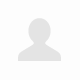
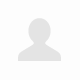
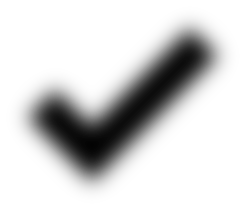
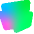
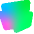
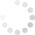

In [180]:
soup = get_reply()